# [LAB-10] 6. [PBT] Apple Quality (2)

## 이전 작업 과정 로드

새로운 파일에서 코드를 작성할 경우 기존 파일과 흐름이 이어지도록 구성

In [1]:
%%capture cap
%run "./[LAB-10] 로지스틱 회귀ㅣ06-[PBT] Apple Quality(1)(실습코드).ipynb"

## #08. 로지스틱 회귀 기준선 모형

### 1. 종속변수 라벨링

- 로지스틱 회귀의 종속변수는 **0/1의 정수**여야 한다. 문자열 `good`/`bad`를 숫자로 바꾼다.
- `my_prep.labeling()`은 **알파벳 순서**로 0부터 매긴다. → `bad = 0`, `good = 1`
- 즉 이 모형이 예측하는 것은 **P(Quality = good)** 이고,
  뒤에 나오는 오즈비는 모두 **"사과가 `good`일 오즈"** 에 대한 값이다.

In [2]:
base = my_prep.labeling(df, columns=[target])
base.head()

Quality (2종): bad=0, good=1


,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,-3.970,-2.512,5.346,-1.012,1.845,0.330,-0.492,1
1,-1.195,-2.839,3.664,1.588,0.853,0.868,-0.723,1
2,-0.292,-1.351,-1.738,-0.343,2.839,-0.038,2.622,0
3,-0.657,-2.272,1.325,-0.098,3.638,-3.414,0.791,1
4,1.364,-1.297,-0.385,-0.553,3.031,-1.304,0.502,1


### 2. 기준선 모형 적합

In [3]:
fit_base = my_logit.fit_model(base, y=target)
my_logit.report_variables(fit_base, base)

,종속변수,독립변수,B,βstd,표준오차,z,유의확률,오즈비(OR),OR 95% 하한,OR 95% 상한,공차,VIF
0,Quality,Size,0.649,1.252,0.028,22.993,0.000,1.915,1.811,2.024,0.708,1.413
1,Quality,Sweetness,0.569,1.105,0.027,20.938,0.000,1.766,1.675,1.863,0.677,1.477
2,Quality,Juiciness,0.442,0.854,0.024,18.242,0.000,1.556,1.484,1.632,0.820,1.219
3,Quality,Acidity,-0.294,-0.621,0.021,-13.697,0.000,0.745,0.714,0.777,0.853,1.172
4,Quality,Weight,0.267,0.427,0.028,9.399,0.000,1.306,1.235,1.380,0.742,1.348
5,Quality,Ripeness,-0.127,-0.238,0.025,-5.132,0.000,0.881,0.839,0.925,0.677,1.478
6,Quality,Crunchiness,0.035,0.049,0.030,1.143,0.253,1.035,0.976,1.098,0.821,1.218


#### 💡 인사이트 — EDA에서 탈락했던 변수가 되살아났다

| 변수 | T검정 (단독 비교) | 기준선 모형 (다른 변수 통제) | 판정 |
|---|---|---|---|
| `Size` | p < 0.001 | z = 22.99, p < 0.001 | 그대로 유의 |
| `Sweetness` | p < 0.001 | z = 20.94, p < 0.001 | 그대로 유의 |
| `Juiciness` | p < 0.001 | z = 18.24, p < 0.001 | 그대로 유의 |
| `Ripeness` | p < 0.001 | z = −5.13, p < 0.001 | 그대로 유의 |
| **`Acidity`** | **p = 0.797 (무관)** | **z = −13.70, p < 0.001** | **되살아남** |
| **`Weight`** | **p = 0.928 (무관)** | **z = 9.40, p < 0.001** | **되살아남** |
| `Crunchiness` | p = 0.985 (무관) | p = 0.253 | 유일한 탈락 후보 |

- **T검정에서 "차이가 전혀 없다"고 나왔던 `Acidity`와 `Weight`가 p < 0.001로 강하게 유의**해졌다.
  이것이 **억제효과(suppression)** 다. 다른 변수를 통제하지 않은 단독 비교에서는 효과가 가려져 있었던 것이다.
  - `Acidity`의 오즈비는 **0.745** 로, 산도가 1점 높아지면 `good`일 오즈가 **약 25.5% 감소**한다.
- → **EDA에서 유의하지 않다는 이유만으로 변수를 버리면 안 된다.**
- 유의하지 않은 변수는 `Crunchiness` 하나뿐이지만, **여기서도 아직 지우지 않는다.**

## #09. 가정 검정

### 1. 기준선 모형의 로짓 선형성 검정 (Box-Tidwell)

- 독립변수 x에 `x × ln(x)` 항을 추가해 **그 항이 유의한지** 본다.
  - 유의하면(p < 0.05) 로짓이 직선이 아니라는 뜻 → 변환·제곱항·구간화가 필요하다.

In [4]:
my_logit.test_linear(fit_base, base)

,z,p-value,linearity,위치이동,result
독립변수,,,,,
Size,4.323,0.000,False,True,대립가설 채택 → 로짓 선형성 위배(변환 필요)
Weight,11.161,0.000,False,True,대립가설 채택 → 로짓 선형성 위배(변환 필요)
Sweetness,0.605,0.545,True,True,귀무가설 채택 → 로짓 선형성 위배 근거 없음
Crunchiness,9.851,0.000,False,True,대립가설 채택 → 로짓 선형성 위배(변환 필요)
Juiciness,-8.075,0.000,False,True,대립가설 채택 → 로짓 선형성 위배(변환 필요)
Ripeness,-1.047,0.295,True,True,귀무가설 채택 → 로짓 선형성 위배 근거 없음
Acidity,-5.553,0.000,False,True,대립가설 채택 → 로짓 선형성 위배(변환 필요)


> **결과** — 7종 중 **5종이 위배**다. (`Weight` z = 11.16, `Crunchiness` z = 9.85, `Juiciness` z = −8.08, `Acidity` z = −5.55, `Size` z = 4.32)
> `Sweetness`(p = 0.545)와 `Ripeness`(p = 0.295)만 충족한다.
> **위배가 가장 심한 `Weight`부터 처방한다.**
>
> ※ 이 변수들은 음수를 포함하므로 `ln`의 정의역을 맞추기 위해 **최솟값이 1이 되도록 평행이동**한 뒤 검정된다. (`위치이동 = True`)

### 2. 진단 → 처방 → 검증 → 재진단 루프

In [5]:
fit_fixed = my_logit.fix_linear(base, y=target)

[라운드 1] 위배 5종 → 'Weight' 처방 (z = 11.1613)
    → 제곱항 채택 (제곱항 p = 0.0000, 우도비 p = 0.0000e+00, AIC = 3962.44)
[라운드 2] 위배 5종 → 'Crunchiness' 처방 (z = 9.0855)
    → 제곱항 채택 (제곱항 p = 0.0000, 우도비 p = 0.0000e+00, AIC = 3867.27)
[라운드 3] 위배 3종 → 'Juiciness' 처방 (z = -10.5276)
    → 제곱항 채택 (제곱항 p = 0.0000, 우도비 p = 0.0000e+00, AIC = 3744.33)
[라운드 4] 위배 3종 → 'Acidity' 처방 (z = -7.4836)
    → 제곱항 채택 (제곱항 p = 0.0000, 우도비 p = 3.2307e-14, AIC = 3688.74)
[라운드 5] 위배 2종 → 'Ripeness' 처방 (z = -3.0869)
    → 제곱항 채택 (제곱항 p = 0.0023, 우도비 p = 2.1255e-03, AIC = 3681.30)
[라운드 6] 위배 1종 → 'Size' 처방 (z = 2.9542)
    → 제곱항 채택 (제곱항 p = 0.0025, 우도비 p = 2.2468e-03, AIC = 3673.97)
[라운드 7] 위배 변수 없음 → 루프 종료



,변수,처방,제곱항 p,검증 p,AIC,채택
라운드,,,,,,
1,Weight,제곱항,0.000,0.000,3962.440,True
2,Crunchiness,제곱항,0.000,0.000,3867.270,True
3,Juiciness,제곱항,0.000,0.000,3744.330,True
4,Acidity,제곱항,0.000,0.000,3688.740,True
5,Ripeness,제곱항,0.002,0.002,3681.300,True
6,Size,제곱항,0.003,0.002,3673.970,True


#### 💡 인사이트 — 하나씩 처방하니 `Crunchiness`도 해소됐다

- 6개 라운드에 걸쳐 **`Weight` → `Crunchiness` → `Juiciness` → `Acidity` → `Ripeness` → `Size`** 순으로
  위배가 심한 변수부터 하나씩 처방됐고, **7라운드에서 위배 변수가 사라져 루프가 종료**됐다.
  - `Sweetness`는 끝까지 위배로 잡히지 않아 **원본 그대로 남았다.**
- 라운드마다 위배 변수의 개수가 5 → 5 → 3 → 3 → 2 → 1 → 0으로 줄어드는데, **한 번에 하나씩 줄지 않는다.**
  한 변수를 고치면 다른 변수의 진단이 함께 바뀌기 때문이다. 이것이 재진단을 반드시 해야 하는 이유다.
- 처방 순서도 눈여겨볼 만하다. `Crunchiness`는 **T검정에서 p = 0.985로 완전 무관**이었고
  **기준선 모형에서도 p = 0.253으로 제거 후보**였는데, 로짓 선형성 진단에서는 **두 번째로 심한 위배**로 잡힌다.
  - 양 극단이 모두 `good` 쪽이라 평균 비교로는 상쇄되어 보이지 않았을 뿐이다.

### 3. 계층 원칙

- 제곱항을 넣으면 1차항이 유의하지 않게 나오는 경우가 있다. 후진소거법이라면 제거 대상이다.
- 하지만 **제곱항이 모형에 있으면 1차항은 유의하지 않아도 남긴다.** 이것을 **계층 원칙(hierarchy principle)** 이라 한다.
  - 1차항을 빼면 곡선의 **꼭짓점이 중심값에 고정**되어 버려, 데이터가 말하는 곡선 모양을 왜곡한다.
- 실제로 지워도 되는지는 **#10의 성능 비교표**에서 후진소거 적용 모형과 나란히 놓고 판단한다.

### 4. 관측치의 독립성 — Durbin-Watson

In [6]:
my_logit.test_independent(fit_fixed)

,statistic,independence,result
Durbin-Watson,2.022,True,독립성 만족


> **결과** — DW = **2.02**로 기준 범위(1.5 ~ 2.5)의 한가운데다. → **독립성 만족.**
> 사과 4,000개는 서로 다른 개체이고 수집 순서에 의미가 없으므로 설계상으로도 독립이 타당하다.

### 5. 가정 검정 결과 확정

- 처방 대상 변수 목록을 확정한다. 이 목록이 **다음 단계 파이프라인의 옵션**이 된다.

In [7]:
# 확정된 처방 내역 (변수별 처방 방식과 기준값)
recipe = fit_fixed.recipe_

for col, rule in recipe.items():
    print(f"{col:14s} : {rule['method']}")

extra_cols = [c for c in continuous_cols if c not in recipe]
print("\n처방 제외 (선형성 충족) :", extra_cols)
print("미해소 (구간화·스플라인 필요) :", fit_fixed.unresolved_)

Weight         : square
Crunchiness    : square
Juiciness      : square
Acidity        : square
Ripeness       : square
Size           : square

처방 제외 (선형성 충족) : ['Sweetness']
미해소 (구간화·스플라인 필요) : []


## #10. 로지스틱 회귀 파이프라인

### 1. 전처리 체크포인트 정의

- 전처리 단계를 하나씩 누적한 체크포인트 (아래로 갈수록 전처리가 하나 더 붙는다)
- **0~3번은 가정 검정을 반영하지 않은 조합**, **4~7번은 `recipe`를 적용한 조합**이다.
  - 두 계열의 전처리 조합을 **동일하게 맞춰** 로짓 선형성 처방의 순수한 효과를 볼 수 있게 한다.
- 공선성 제거(`vif=True`)는 **모든 체크포인트에 공통으로** 걸어 둔다.
  - #06에서 이미 제거 대상이 없음을 확인했으므로, 별도의 비교 단계로 쪼갤 이유가 없다.

In [8]:
checkpoints = {
    # --- 가정 검정 미반영 ---
    "0_기준선":             dict(vif=True),
    "1_후진소거":           dict(backward=True, vif=True),
    "2_이상치대체":         dict(backward=True, outlier=True, vif=True),
    "3_정규화":             dict(backward=True, outlier=True, vif=True, scale=True),

    # --- 가정 검정 반영 (로짓 선형성 처방) ---
    "4_가정반영":           dict(recipe=recipe, vif=True),
    "5_가정반영+후진소거":   dict(recipe=recipe, backward=True, vif=True),
    "6_가정반영+이상치대체": dict(recipe=recipe, backward=True, outlier=True, vif=True),
    "7_가정반영+정규화":     dict(recipe=recipe, backward=True, outlier=True, vif=True, scale=True),
}

### 2. 체크포인트별 모델 적합

In [9]:
fits = {}    # 적합된 모델을 누적할 딕셔너리

for name in checkpoints:
    print(f"\n▶︎ --- {name} ---")

    fits[name] = my_logit.fit_pipeline(
        base, target, continuous_cols, name=name, **checkpoints[name])

print("\n누적된 모델 :", len(fits), "개")


▶︎ --- 0_기준선 ---

완료! 남은 변수: ['Acidity', 'Crunchiness', 'Juiciness', 'Ripeness', 'Size', 'Sweetness', 'Weight']
최대 VIF = 1.48


▶︎ --- 1_후진소거 ---

완료! 남은 변수: ['Acidity', 'Crunchiness', 'Juiciness', 'Ripeness', 'Size', 'Sweetness', 'Weight']
최대 VIF = 1.48

유의하지 않은 독립변수 제거 → Crunchiness (p = 0.2532)

▶︎ --- 2_이상치대체 ---

완료! 남은 변수: ['Acidity', 'Crunchiness', 'Juiciness', 'Ripeness', 'Size', 'Sweetness', 'Weight']
최대 VIF = 1.47

유의하지 않은 독립변수 제거 → Crunchiness (p = 0.3016)

▶︎ --- 3_정규화 ---

완료! 남은 변수: ['Acidity', 'Crunchiness', 'Juiciness', 'Ripeness', 'Size', 'Sweetness', 'Weight']
최대 VIF = 1.47

유의하지 않은 독립변수 제거 → Crunchiness (p = 0.3016)

▶︎ --- 4_가정반영 ---

완료! 남은 변수: ['Acidity_c', 'Acidity_c2', 'Crunchiness_c', 'Crunchiness_c2', 'Juiciness_c', 'Juiciness_c2', 'Ripeness_c', 'Ripeness_c2', 'Size_c', 'Size_c2', 'Sweetness', 'Weight_c', 'Weight_c2']
최대 VIF = 1.61


▶︎ --- 5_가정반영+후진소거 ---

완료! 남은 변수: ['Acidity_c', 'Acidity_c2', 'Crunchiness_c', 'Crunchiness_c2', 'Juiciness_c', 'Juiciness_c2'

### 3. 전체 모델 성능 비교

- 성능을 바꾼 것은 전처리가 아니라 가정 검정이었다

In [10]:
best = my_logit.compare_models(fits)
print("간명성 기준 1순위 :", best.name_)

,변수수,정확도,정밀도,재현율,F1,AUC,Pseudo R²,AIC,Gap(%)
모델,,,,,,,,,
5_가정반영+후진소거,12,0.791,0.784,0.804,0.794,0.868,0.343,3672.041,0.000
6_가정반영+이상치대체,12,0.793,0.787,0.805,0.796,0.868,0.341,3677.811,0.060
7_가정반영+정규화,12,0.793,0.787,0.805,0.796,0.868,0.341,3677.811,0.060
4_가정반영,13,0.792,0.785,0.804,0.795,0.868,0.343,3673.968,0.000
0_기준선,7,0.749,0.741,0.766,0.753,0.824,0.258,4129.557,5.080
1_후진소거,6,0.750,0.742,0.767,0.754,0.824,0.258,4128.863,5.090
2_이상치대체,6,0.749,0.741,0.766,0.754,0.823,0.257,4136.292,5.170
3_정규화,6,0.749,0.741,0.766,0.754,0.823,0.257,4136.292,5.170


간명성 기준 1순위 : 5_가정반영+후진소거


### 4. 최종 모델 선택

- `my_logit.compare_models()`는 근소 격차 그룹 안에서 **변수가 하나 적은 `5_가정반영+후진소거`를 1순위**로 지목한다.
- 하지만 5번이 지운 변수는 제곱항의 짝인 `Crunchiness_c`이므로, **계층 원칙**(#09-3)에 따라 **4번을 채택**한다.
  - AIC 차이는 **1.93**(3673.97 → 3672.04)에 불과해, 변수 하나를 지워 얻는 이득이 거의 없다.
  - → **간명성 규칙이 통계적 원칙보다 앞설 수는 없다.** 자동 선택 결과는 언제나 분석자가 검토해야 한다.

In [11]:
# 계층 원칙에 따라 4번을 최종 채택한다
final_name = "4_가정반영"

final_fit = fits[final_name]
final_data = final_fit.data_       # 전처리가 끝난 데이터 (보고에 사용)

print("최종 모델 :", final_name)
print("독립변수  :", int(final_fit.df_model), "개")

최종 모델 : 4_가정반영
독립변수  : 13 개


## #11. 최종 채택 모델에 대한 결과 보고

### 1. 모형 적합도

In [12]:
Markdown(my_logit.report_fitness(final_fit))

**Note. n = 4000. LL = -1822.984, LL-Null = -2772.581, LLR χ²(13) = 1899.193, p < 0.001, Pseudo R² = 0.342**

Quality를 종속변수로, Sweetness, Weight_c, Weight_c2, Crunchiness_c, Crunchiness_c2, Juiciness_c, Juiciness_c2, Acidity_c, Acidity_c2, Ripeness_c, Ripeness_c2, Size_c, Size_c2(을)를 독립변수로 한 로지스틱 회귀분석 결과, 모형은 통계적으로 유의하였다.

> LLR χ²(13) = 1899.193, p < 0.001, Pseudo R² = 0.342.

즉, 모형의 유사결정계수는 0.342로 매우 우수한 적합 수준을 보였다.

> ※ Pseudo R²는 선형회귀의 R²처럼 '분산 설명 비율'로 해석하지 않는다. 일반적으로 **0.2~0.4** 구간이면 매우 우수한 적합으로 본다.

### 2. 독립변수 보고

In [13]:
display(my_logit.report_variables(final_fit, final_data))
Markdown(my_logit.report_variables_text(final_fit, data=final_data))

,종속변수,독립변수,B,βstd,표준오차,z,유의확률,오즈비(OR),OR 95% 하한,OR 95% 상한,공차,VIF
0,Quality,Size_c,0.629,1.214,0.031,20.410,0.000,1.876,1.766,1.993,0.664,1.506
1,Quality,Sweetness,0.568,1.105,0.030,18.806,0.000,1.766,1.664,1.873,0.646,1.547
2,Quality,Juiciness_c,0.485,0.937,0.027,17.805,0.000,1.625,1.540,1.714,0.787,1.270
3,Quality,Acidity_c,-0.274,-0.578,0.023,-11.889,0.000,0.760,0.727,0.795,0.831,1.203
4,Quality,Crunchiness_c2,0.192,0.625,0.019,10.399,0.000,1.212,1.169,1.257,0.922,1.084
5,Quality,Ripeness_c,-0.184,-0.345,0.029,-6.378,0.000,0.832,0.786,0.880,0.622,1.609
6,Quality,Weight_c2,0.176,0.693,0.015,11.948,0.000,1.192,1.158,1.227,0.951,1.051
7,Quality,Weight_c,0.165,0.264,0.033,4.945,0.000,1.179,1.105,1.259,0.702,1.424
8,Quality,Juiciness_c2,-0.103,-0.547,0.010,-9.991,0.000,0.902,0.884,0.920,0.884,1.131
9,Quality,Acidity_c2,-0.061,-0.375,0.008,-7.590,0.000,0.941,0.926,0.956,0.893,1.120


- **Sweetness**의 회귀계수는 **B = 0.5685**, 오즈비는 **OR = 1.7656**로 나타났으며, 이는 **Quality**에 유의한 요인임을 의미한다.      
(**z = 18.81**, **p < .001**)      
즉, **Sweetness**가 1 증가할 때 Quality가 1(사건 발생)이 될 오즈는 평균적으로 약 **76.6% 증가**하는 것으로 해석된다.
- **Weight_c**의 회귀계수는 **B = 0.165**, 오즈비는 **OR = 1.1794**로 나타났으며, 이는 **Quality**에 유의한 요인임을 의미한다.      
(**z = 4.94**, **p < .001**)      
즉, **Weight_c**가 1 증가할 때 Quality가 1(사건 발생)이 될 오즈는 평균적으로 약 **17.9% 증가**하는 것으로 해석된다.
- **Weight_c2**의 회귀계수는 **B = 0.1758**, 오즈비는 **OR = 1.1922**로 나타났으며, 이는 **Quality**에 유의한 요인임을 의미한다.      
(**z = 11.95**, **p < .001**)      
즉, **Weight_c2**가 1 증가할 때 Quality가 1(사건 발생)이 될 오즈는 평균적으로 약 **19.2% 증가**하는 것으로 해석된다.
- **Crunchiness_c**의 회귀계수는 **B = 0.0097**, 오즈비는 **OR = 1.0098**로 나타났으며, 이는 **Quality**에 유의하지 않은 요인임을 의미한다.      
(**z = 0.27**, **p = .787**)      
즉, **Crunchiness_c**가 1 증가할 때 Quality가 1(사건 발생)이 될 오즈는 평균적으로 약 **1.0% 증가**하는 것으로 해석된다.
- **Crunchiness_c2**의 회귀계수는 **B = 0.1925**, 오즈비는 **OR = 1.2122**로 나타났으며, 이는 **Quality**에 유의한 요인임을 의미한다.      
(**z = 10.4**, **p < .001**)      
즉, **Crunchiness_c2**가 1 증가할 때 Quality가 1(사건 발생)이 될 오즈는 평균적으로 약 **21.2% 증가**하는 것으로 해석된다.
- **Juiciness_c**의 회귀계수는 **B = 0.4853**, 오즈비는 **OR = 1.6247**로 나타났으며, 이는 **Quality**에 유의한 요인임을 의미한다.      
(**z = 17.81**, **p < .001**)      
즉, **Juiciness_c**가 1 증가할 때 Quality가 1(사건 발생)이 될 오즈는 평균적으로 약 **62.5% 증가**하는 것으로 해석된다.
- **Juiciness_c2**의 회귀계수는 **B = -0.1031**, 오즈비는 **OR = 0.902**로 나타났으며, 이는 **Quality**에 유의한 요인임을 의미한다.      
(**z = -9.99**, **p < .001**)      
즉, **Juiciness_c2**가 1 증가할 때 Quality가 1(사건 발생)이 될 오즈는 평균적으로 약 **9.8% 감소**하는 것으로 해석된다.
- **Acidity_c**의 회귀계수는 **B = -0.274**, 오즈비는 **OR = 0.7603**로 나타났으며, 이는 **Quality**에 유의한 요인임을 의미한다.      
(**z = -11.89**, **p < .001**)      
즉, **Acidity_c**가 1 증가할 때 Quality가 1(사건 발생)이 될 오즈는 평균적으로 약 **24.0% 감소**하는 것으로 해석된다.
- **Acidity_c2**의 회귀계수는 **B = -0.061**, 오즈비는 **OR = 0.9408**로 나타났으며, 이는 **Quality**에 유의한 요인임을 의미한다.      
(**z = -7.59**, **p < .001**)      
즉, **Acidity_c2**가 1 증가할 때 Quality가 1(사건 발생)이 될 오즈는 평균적으로 약 **5.9% 감소**하는 것으로 해석된다.
- **Ripeness_c**의 회귀계수는 **B = -0.184**, 오즈비는 **OR = 0.8319**로 나타났으며, 이는 **Quality**에 유의한 요인임을 의미한다.      
(**z = -6.38**, **p < .001**)      
즉, **Ripeness_c**가 1 증가할 때 Quality가 1(사건 발생)이 될 오즈는 평균적으로 약 **16.8% 감소**하는 것으로 해석된다.
- **Ripeness_c2**의 회귀계수는 **B = -0.0309**, 오즈비는 **OR = 0.9696**로 나타났으며, 이는 **Quality**에 유의한 요인임을 의미한다.      
(**z = -3.02**, **p = .002**)      
즉, **Ripeness_c2**가 1 증가할 때 Quality가 1(사건 발생)이 될 오즈는 평균적으로 약 **3.0% 감소**하는 것으로 해석된다.
- **Size_c**의 회귀계수는 **B = 0.6294**, 오즈비는 **OR = 1.8765**로 나타났으며, 이는 **Quality**에 유의한 요인임을 의미한다.      
(**z = 20.41**, **p < .001**)      
즉, **Size_c**가 1 증가할 때 Quality가 1(사건 발생)이 될 오즈는 평균적으로 약 **87.6% 증가**하는 것으로 해석된다.
- **Size_c2**의 회귀계수는 **B = 0.029**, 오즈비는 **OR = 1.0294**로 나타났으며, 이는 **Quality**에 유의한 요인임을 의미한다.      
(**z = 3.02**, **p = .003**)      
즉, **Size_c2**가 1 증가할 때 Quality가 1(사건 발생)이 될 오즈는 평균적으로 약 **2.9% 증가**하는 것으로 해석된다.

> ※ 오즈비(OR)가 1보다 크면 사건 발생 오즈가 증가, 1보다 작으면 감소함을 뜻한다. 유의확률이 유의수준보다 큰(=유의하지 않은) 변수는 효과가 통계적으로 확인되지 않았으므로 오즈비 해석에 주의한다. 더미변수의 오즈비는 '기준(drop_first로 제외된) 범주' 대비 값이다.

> ※ **오즈비(OR)의 크기로 변수의 영향력을 비교하면 안 된다.**
> 변수 간 값의 범위가 동일한 경우만 오즈비를 직접 비교할 수 있다.
> 값의 범위가 서로 다르면 범위를 통일한 **표준화 계수(βstd)** 로 영향력을 비교해야 한다.

### 3. 오즈비 시각화

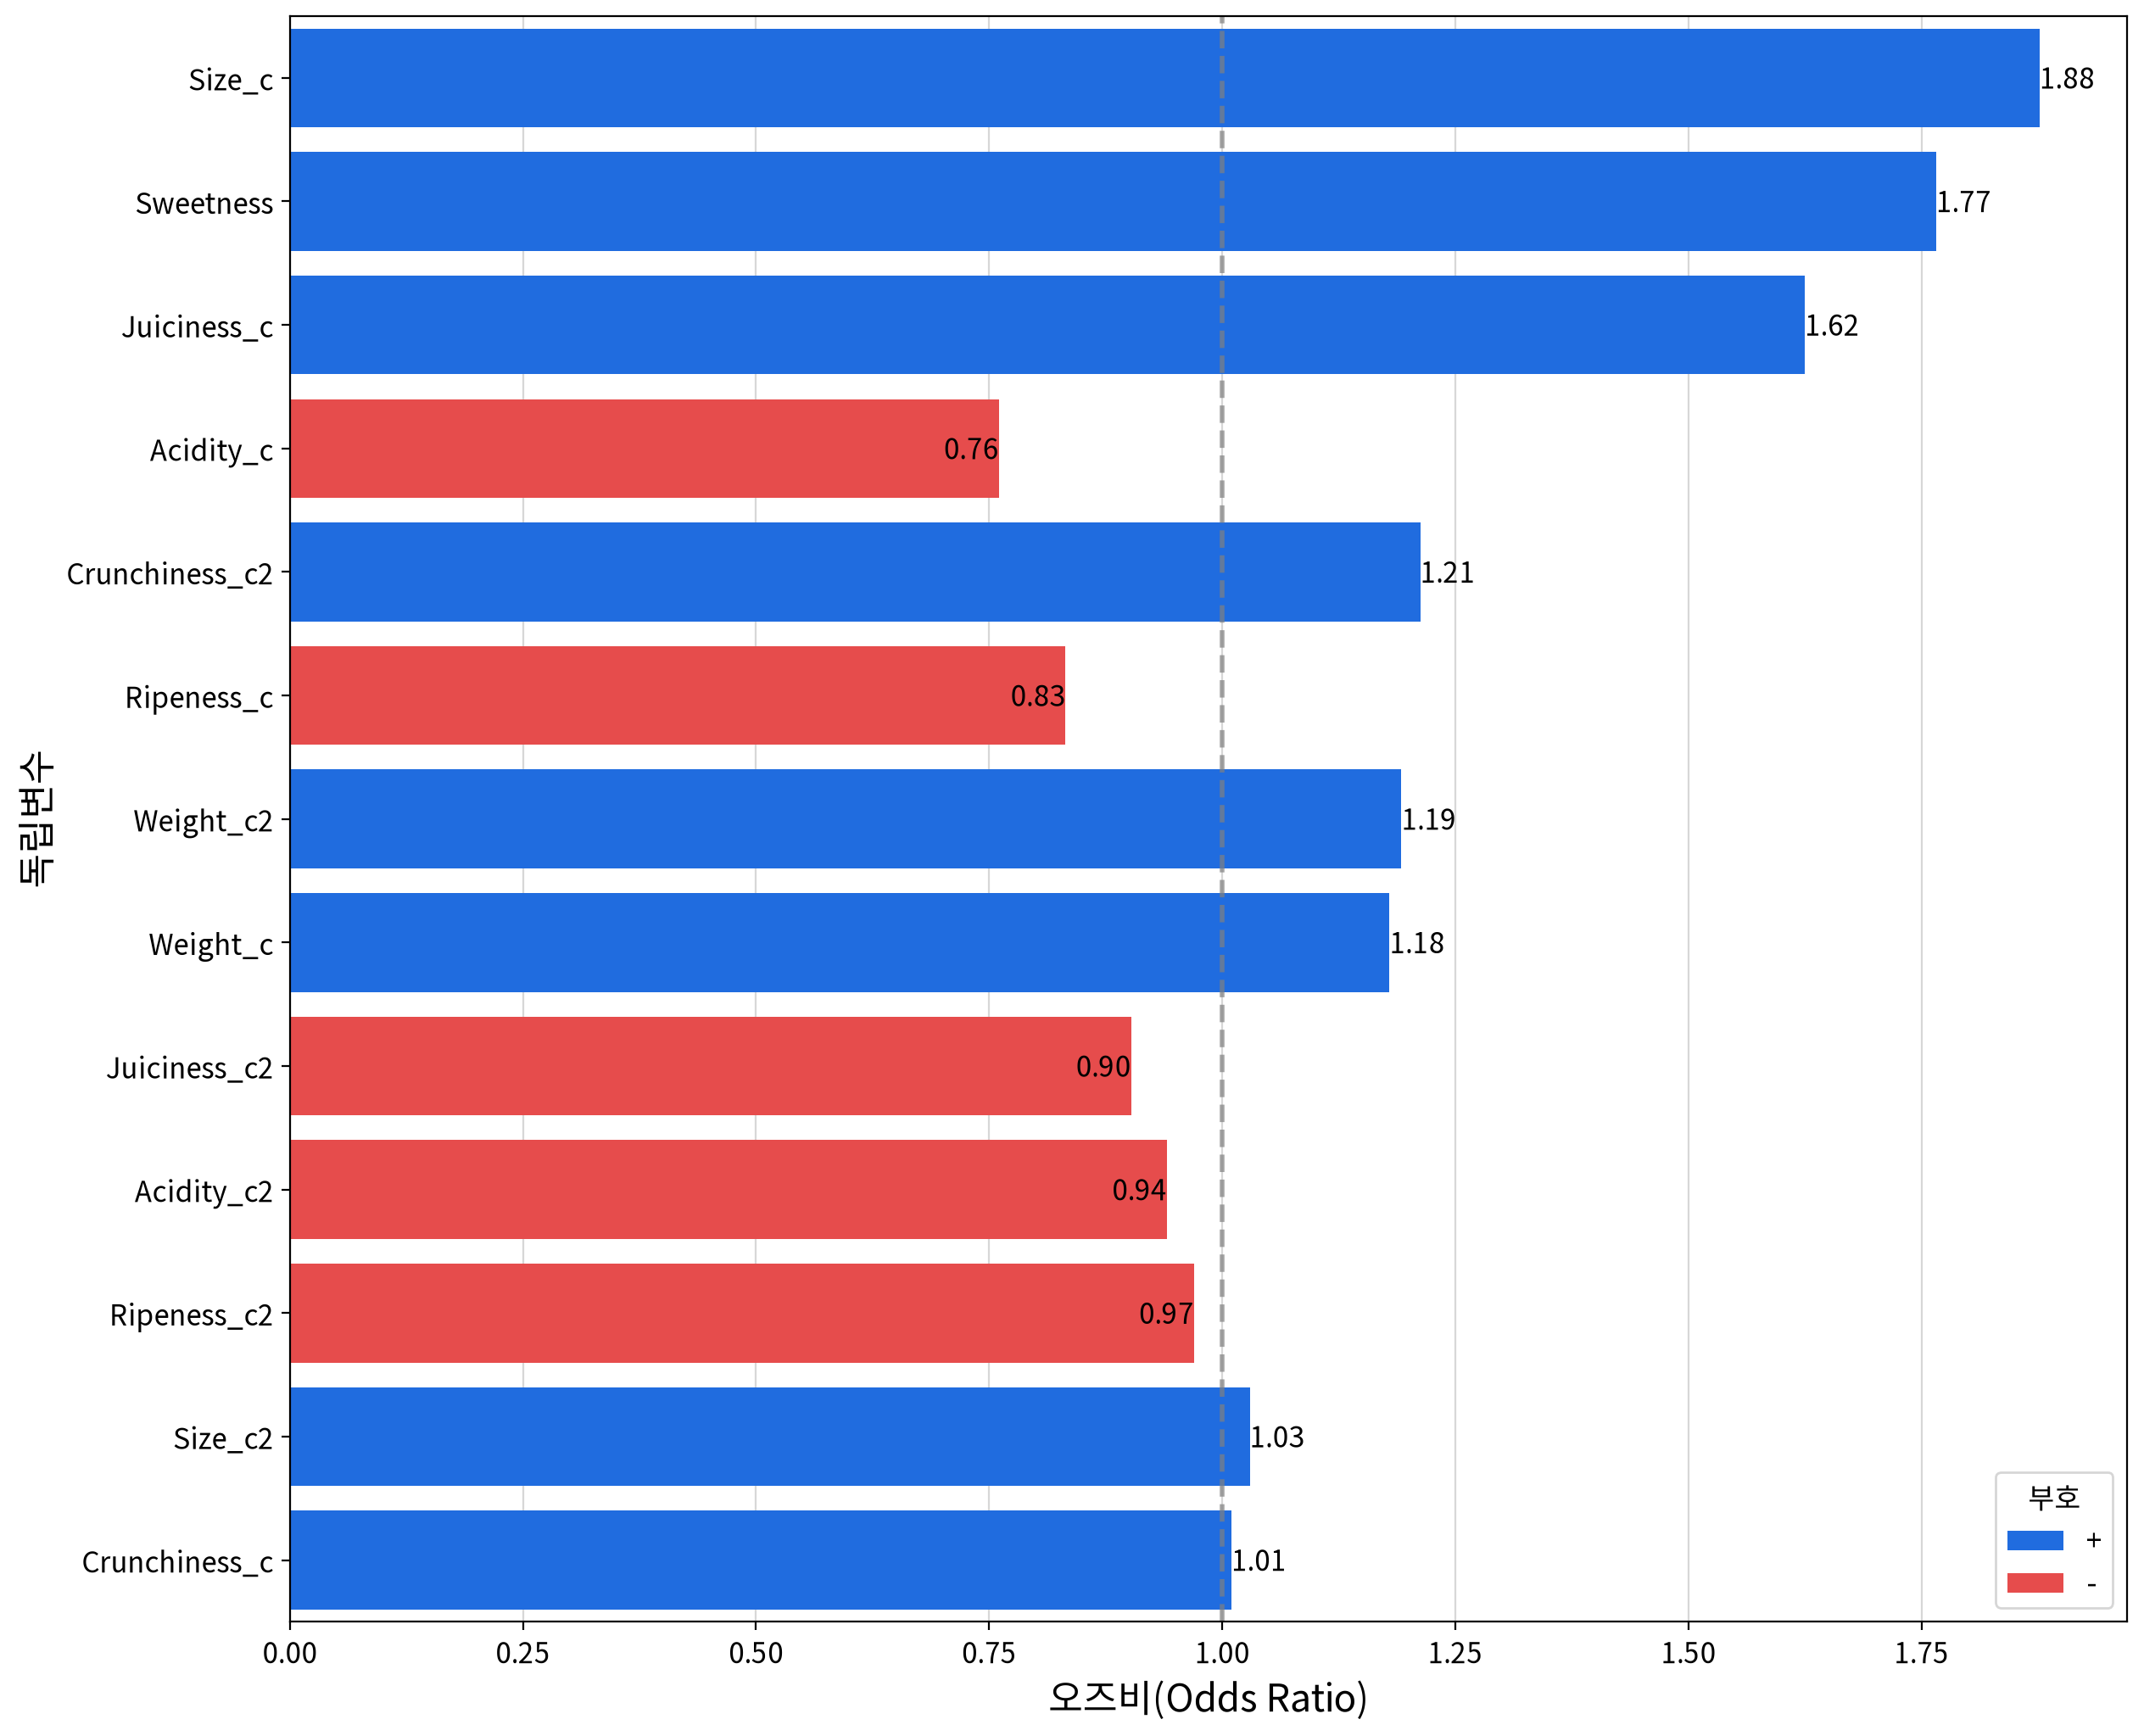

In [14]:
my_logit.plot_odds(final_fit, final_data)

#### 💡 인사이트 — 계수 해석

**모형 요약** — `logit(P(Quality = good)) ~ Sweetness + (Size·Weight·Crunchiness·Juiciness·Ripeness·Acidity의 1차항 + 제곱항)`

- **LLR χ²(13) = 1,899.19, p < .001, Pseudo R² = 0.342** 로 매우 우수한 적합이다. 13개 중 12개가 유의하다.
- **영향력 1위는 `Size`** 다. 표준화 계수 βstd = 1.214로 2위 `Sweetness`(1.105)와 근소하고,
  이어서 `Juiciness`(0.937) 순이다. **크기·단맛·과즙이 품질을 결정하는 3대 축**이다.

**1차항만 있는 변수 (직선 관계)**

| 변수 | 오즈비 | 해석 |
|---|---|---|
| `Sweetness` | 1.766 | 단맛 1점 ↑ → `good`일 오즈 **76.6% 증가** |

**1차항 + 제곱항이 있는 변수 (곡선 관계)**

⚠️ 제곱항이 있는 변수는 **오즈비를 한 줄로 해석하지 않는다.** 두 계수가 함께 곡선을 만든다.

| 변수 | 1차항 B | 제곱항 B | 곡선 모양 | 해석 |
|---|---|---|---|---|
| `Size` | +0.629 | +0.029 | 아래로 볼록 ∪ | 클수록 좋고, 커질수록 **가속**된다 |
| `Weight` | +0.165 | +0.176 | 아래로 볼록 ∪ | 평균에서 **양쪽으로 멀어질수록** 좋다 |
| `Crunchiness` | +0.010 (n.s.) | +0.192 | 아래로 볼록 ∪ | 아삭함은 **극단(아주 아삭하거나 아주 무르거나)** 이 좋다 |
| `Juiciness` | +0.485 | −0.103 | 위로 볼록 ∩ | 과즙은 많을수록 좋지만 **어느 지점부터 효과가 꺾인다** |
| `Ripeness` | −0.184 | −0.031 | 위로 볼록 ∩ | 덜 익을수록 좋고, **과숙일수록 급격히 나빠진다** |
| `Acidity` | −0.274 | −0.061 | 위로 볼록 ∩ | 산도가 높을수록 나쁘고, **높아질수록 가속**된다 |

- **`Crunchiness`가 이 분석의 가장 큰 반전이다.**
  T검정 p = 0.985(완전 무관), 기준선 모형 p = 0.253(제거 대상)이었던 변수가
  **제곱항을 넣자 z = 10.40으로 세 번째로 강한 예측 변수**가 됐다.
  1차항으로만 보면 효과가 없는 이유는, **양 극단이 모두 `good` 쪽이라 평균적으로 상쇄**되기 때문이다.
- 이것은 EDA와 모델링 단계에서 각각 다른 이유로 놓칠 수 있었던 변수다.
  - EDA(T검정) → 평균 비교라서 U자 관계를 못 본다.
  - 기준선 모형 → 직선만 표현하므로 역시 못 본다.
  - **가정 검정(Box-Tidwell)에서만 잡힌다.**

### 4. 분류 성능 평가

,예측 0 (Negative),예측 1 (Positive)
실제 0 (Negative),1555,441
실제 1 (Positive),392,1612


,정확도(Accuracy),정밀도(Precision),"재현율(Recall,TPR)","위양성율(Fallout,FPR)","특이성(Specificity,TNR)",F1,AUC,AUC 판단,진단오즈비(DOR)
performance,0.792,0.785,0.804,0.221,0.779,0.795,0.868,우수,14.500


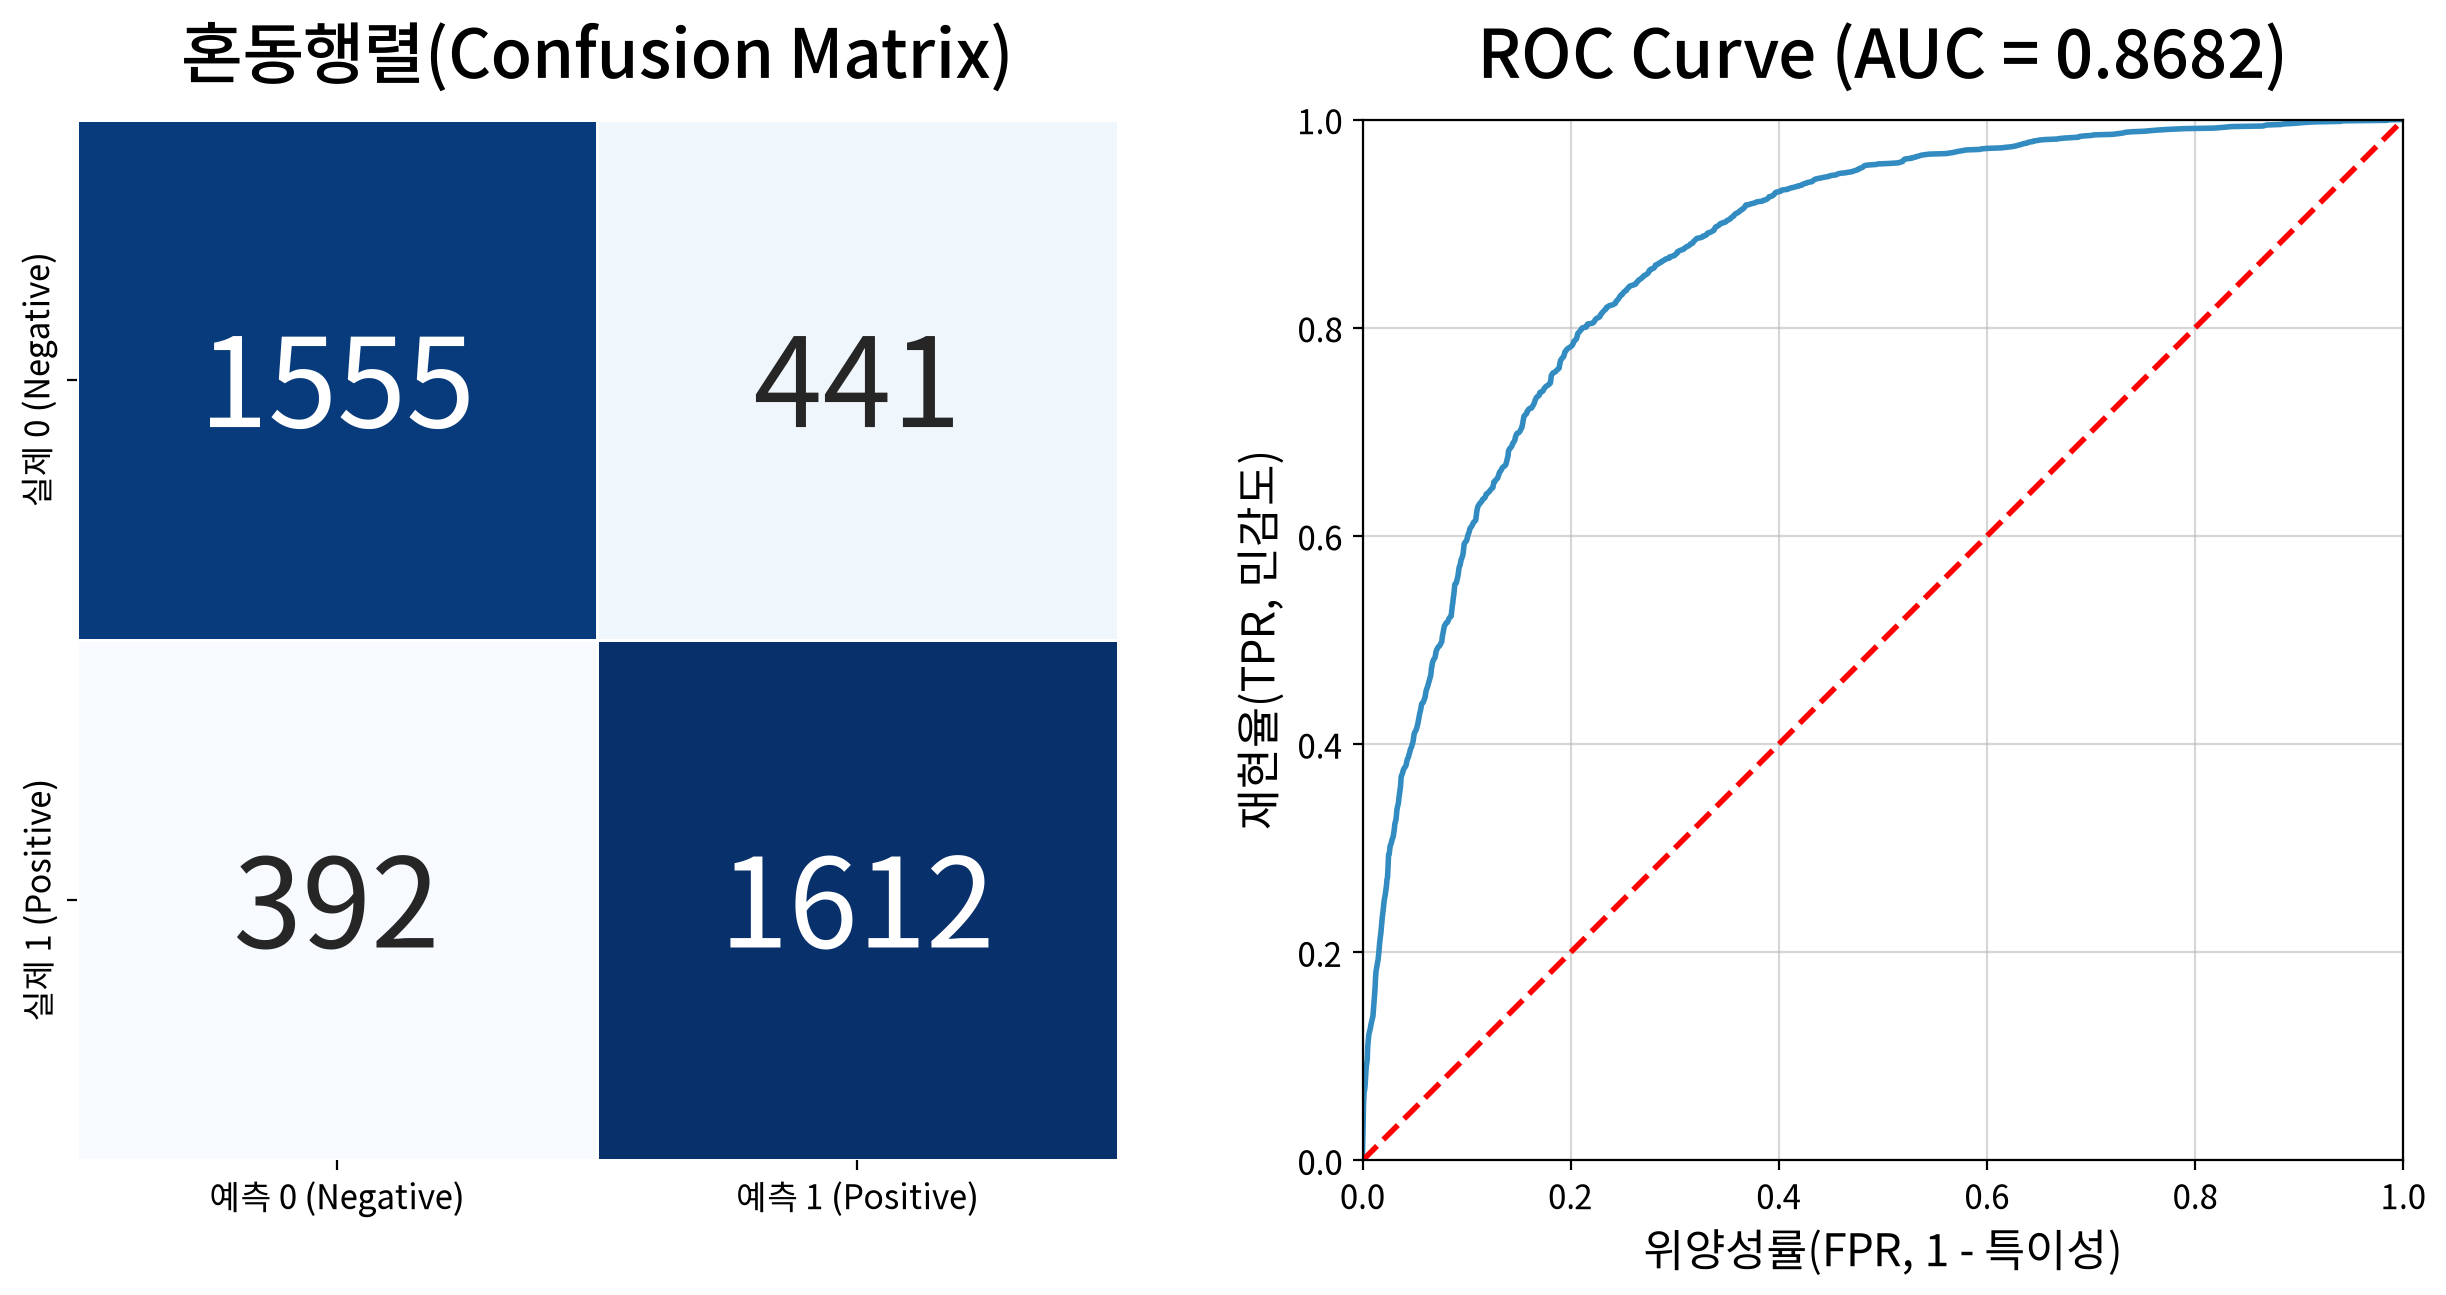

In [15]:
my_logit.report_performance(final_fit)

#### 💡 인사이트

- **정확도 0.792** — 4,000개 중 3,167개를 맞혔다. 게으른 모형의 바닥값 50.1%보다 **29%p 높다.**
- **AUC 0.868 (우수)** — `good` 사과 하나와 `bad` 사과 하나를 무작위로 뽑았을 때,
  모형이 `good` 쪽에 더 높은 확률을 줄 가능성이 **86.8%** 다.
- **정밀도 0.785 · 재현율 0.804 · 특이성 0.779로 네 지표가 고르다.**
  균형 데이터이기 때문에 나타나는 특징이다. (불균형 데이터였던 당뇨 예제에서는 재현율만 0.57로 처졌었다)
- **진단 오즈비 14.50** — 모형이 `good`이라고 판정한 사과가 실제로 `good`일 오즈는
  `bad`라고 판정한 사과의 **약 14.5배**다.

### 5. 임계값 조정

- 임계값 0.5는 관례일 뿐 **정답이 아니다.** 목적에 따라 조정한다.

In [20]:
my_logit.report_threshold(final_fit)

,정확도,정밀도,재현율,F1,놓친 1(FN),잘못 잡은 0(FP)
임계값,,,,,,
0.300,0.765,0.699,0.932,0.799,137,803
0.400,0.784,0.740,0.875,0.802,250,615
0.500,0.792,0.785,0.804,0.795,392,441
0.600,0.779,0.822,0.713,0.764,575,309
0.700,0.747,0.857,0.594,0.702,813,198


#### 💡 인사이트

- **정확도는 0.5에서 최대(0.792)** 지만, **F1은 0.4에서 최대(0.802)** 다.
- **트레이드오프가 그대로 나타난다.** 임계값 0.3 → 재현율 0.932 / 정밀도 0.699,
  임계값 0.7 → 정밀도 0.857 / 재현율 0.594.
- **정답은 목적이 정한다.**
  - **프리미엄 등급 선별**(내보내는 사과는 반드시 `good`이어야 함) → 임계값을 **높여** 정밀도 확보
  - **폐기 대상 걸러내기**(좋은 사과를 버리면 손해) → 임계값을 **낮춰** 재현율 확보

## #12. 한계점

- **처방을 고르는 절차가 자동 규칙에 의존한다.** 제곱항과 로그 변환 중 AIC가 낮은 쪽을 고르도록 했지만,
  실제로는 **로짓 대비 산점도의 모양을 보고 판단**하는 것이 원칙이다. 이 데이터는 7종 모두 음수를 포함해
  로그 변환이 후보에서 빠졌으므로, 사실상 제곱항 외의 선택지가 없었다.
- **제곱항을 6개 추가하면서 모형이 복잡해졌다.** 곡선을 표현할 수 있게 된 대신
  변수당 계수가 2개로 늘어 **오즈비를 한 줄로 해석할 수 없게 됐고**, 과적합 위험도 함께 올라갔다.
- **성능을 학습 데이터에서 그대로 측정했다.** 훈련·검증 데이터를 나누지 않았으므로
  정확도 0.792와 AUC 0.868은 **낙관적인 값**이다. 제곱항 6개를 추가하면서 과적합 위험도 함께 올라갔다.
- **변수의 물리적 의미를 알 수 없다.** 값이 이미 표준화된 상태로 제공되어
  "크기 1점"이 몇 mm인지, "산도 1점"이 pH 얼마인지 알 수 없다. **오즈비를 현장 단위로 환산할 수 없다.**
- **품질 라벨의 기준이 공개되어 있지 않다.** `good`/`bad`를 누가 어떤 기준으로 판정했는지 모르므로,
  모형이 학습한 것은 "사과의 객관적 품질"이 아니라 **"이 데이터를 만든 사람의 판정 기준"** 일 수 있다.
- **인과관계가 아니라 연관관계다.** 산도를 인위적으로 낮춘다고 사과가 `good`이 되지는 않는다.